# Model Context Protocol (MCP)

- MCP, is an open standard designed to enable seamless, secure, and structured **communication between AI-powered applications**—most notably large language models (LLMs)—and **external data sources or tools**.

- MCP works by defining a universal client-server architecture: AI applications (acting as **MCP clients**) interact with various external systems (**MCP servers**), which expose specific tools, data resources, or reusable prompts. [^1] [^3] [^5] [^6] [^7]

- The protocol, built on [JSON-RPC 2.0](https://www.jsonrpc.org/specification), acts as a common “language” allowing AI assistants to **call functions, fetch real-time data, or use predefined templates** from any connected service in a standardized way. This makes it far easier for LLM-based agents to access up-to-date information and capabilities without custom coding for each integration, similar to how USB provides a universal connector for computer peripherals. MCP has quickly gained traction in both open-source and commercial AI ecosystems and is a foundational technology for modern agentic AI systems and enhanced LLM deployments. [^4] [^5] [^6] [^7]

See also this [podcast](https://talkpython.fm/episodes/show/527/mcp-servers-for-python-devs).

[^1]: https://opencv.org/blog/model-context-protocol/

[^2]: https://modelcontextprotocol.io

[^3]: https://www.anthropic.com/news/model-context-protocol

[^4]: https://www.speakeasy.com/mcp/core-concepts

[^5]: https://www.descope.com/learn/post/mcp

[^6]: https://www.digitalocean.com/community/tutorials/model-context-protocol

[^7]: https://stytch.com/blog/model-context-protocol-introduction/

[^8]: https://www.reddit.com/r/ClaudeAI/comments/1ioxu5r/still_confused_about_how_mcp_works_heres_the/

[^9]: https://www.youtube.com/watch?v=CDjjaTALI68



In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # Add My Drive/<>

import os
os.chdir('drive/My Drive')
os.chdir('Books_Writings/NLPBook/')

Mounted at /content/drive


In [ ]:
%%capture
%pylab inline
import pandas as pd
import os
%load_ext rpy2.ipython
from IPython.display import Image

In [ ]:
import textwrap
def p80(text):
    print(textwrap.fill(text, 80))
    return None

JSON-RPC 2.0 is a lightweight, stateless, and transport-agnostic protocol for making remote procedure calls (RPC) using JSON. It allows a client to call a method on a server and receive a response, using simple JSON objects for messages.

Example MCP JSON-RPC messages for invoking a tool, following the MCP protocol’s structured request-response flow for tool calls:

**Tool Invocation Request (`tools/call`)**

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "method": "tools/call",
  "params": {
    "name": "echo",
    "arguments": {
      "message": "Testing 123"
    }
  }
}
```

This request asks the server to execute the tool named `echo` with the argument `message: "Testing 123"`.

**Successful Invocation Response**

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "result": {
    "content": [
      { "type": "text", "text": "Echo: Testing 123" }
    ]
  }
}
```

The server replies with the results of the tool execution. The output structure is determined by the tool’s API definition.

**Error Response Example**

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "error": {
    "code": 404,
    "message": "Tool not found"
  }
}
```



## MCP components

MCP (Model Context Protocol) has a modular architecture built around three main components: the Host, Client, and Server. Each has a distinct role for enabling secure and structured communication between AI applications and external resources or tools. [^1] [^2] [^3]

**Host**

The Host is the user-facing AI application or environment, such as Claude Desktop, an AI-powered IDE, or a custom agent application. Its responsibilities include managing user interactions, orchestrating the flow between LLM processing and tool calls, initiating client-server connections, and enforcing security boundaries. The Host coordinates the entire protocol lifecycle and ensures the user experience remains seamless. [^4] [^3] [^1]. See https://github.com/mcp/github/github-mcp-server for hosts such as VSCode.

**Client**

The Client *resides within the Host* application and is responsible for implementing the MCP protocol and handling one-to-one communication with a specific MCP Server. It manages session states, negotiates capabilities, handles secure data exchange, and routes requests or responses between the Host and Server. Each Client *connects to a single Server*, and Hosts can spawn multiple Clients to interface with multiple Servers. [^5] [^6] [^3]

**Server**

The Server is an independent process, service, or API that exposes functionality, data, or resources to AI models via the MCP protocol. Servers can provide *tools* (actions the AI can perform), *resources* (context or data), or *prompts* (reusable templates), and are responsible for processing incoming requests, executing external actions, and returning results to Clients. Servers work in isolation—focused on specific capabilities—and are designed to be simple, composable, and secure. [^7] [^3] [^4] [^1]

**Additional Layers: Data and Transport**

- **Data Layer**: Handles JSON-RPC-based protocol messaging, including tool/resource/prompt definitions, session management, and notifications. [^5]
- **Transport Layer**: Manages how data is exchanged (e.g., via stdio for local or HTTP+SSE for remote), including connection, framing, and authentication. [^4] [^5]

This clear separation of labor ensures that AI Hosts focus on reasoning, Clients manage secure and stateful interactions, and Servers provide modular, reusable extensions to the AI’s capabilities. [^3] [^7]

[^1]: https://modelcontextprotocol.io/specification/2025-03-26/architecture

[^2]: https://nebius.com/blog/posts/understanding-model-context-protocol-mcp-architecture

[^3]: https://huggingface.co/learn/mcp-course/en/unit1/architectural-components

[^4]: https://www.descope.com/learn/post/mcp

[^5]: https://modelcontextprotocol.io/docs/learn/architecture

[^6]: https://modelcontextprotocol.io/docs/learn/client-concepts

[^7]: https://workos.com/blog/how-mcp-servers-work

[^8]: https://www.anthropic.com/news/model-context-protocol

[^9]: https://www.ibm.com/think/topics/model-context-protocol

[^10]: https://code.visualstudio.com/docs/copilot/customization/mcp-servers



## A list of MCP servers

- A centralized, official source for discovering MCP servers is the MCP Registry, launched in 2025 as an open catalog and API dedicated to publicly available MCP servers. It acts like an app store for MCP servers, providing a single authoritative repository for server metadata, including endpoints, capabilities, and versions. [^1] [^2]

- The MCP Registry is hosted at `registry.modelcontextprotocol.io` and is community-owned with contributions from major organizations like Anthropic, GitHub, and Microsoft. It supports federated discovery through public and private sub-registries, allowing curated marketplaces and enterprise-specific registries to build on top of the shared core metadata. [^2] [^4]

- Anyone can browse the registry via its API to list MCP servers with pagination and search functionality, or developers can publish new servers following the registry’s open API specification. The registry emphasizes trust and moderation, featuring community mechanisms for flagging and removing malicious or spammy entries to maintain ecosystem integrity. [^4] [^1]

See: https://registry.modelcontextprotocol.io

A huge list of MCP servers is here: https://mcpmarket.com/server

From the GitHub page there is also a list of servers: https://github.com/modelcontextprotocol/servers

The GitHub MCP registry is at: https://github.com/mcp


[^1]: http://blog.modelcontextprotocol.io/posts/2025-09-08-mcp-registry-preview/

[^2]: https://modelcontextprotocol.info/tools/registry/

[^3]: https://www.infoq.com/news/2025/09/introducing-mcp-registry/

[^4]: https://workos.com/blog/mcp-registry-architecture-technical-overview

[^5]: https://github.com/modelcontextprotocol/registry

[^6]: https://registry.modelcontextprotocol.io/docs

[^7]: https://code.visualstudio.com/docs/copilot/customization/mcp-servers

[^8]: https://github.blog/ai-and-ml/generative-ai/how-to-find-install-and-manage-mcp-servers-with-the-github-mcp-registry/

[^9]: https://www.anthropic.com/news/model-context-protocol



## Example: YouTube API, no MCP

https://mcpmarket.com/server/youtube-transcript-6

In [ ]:
!pip install youtube_transcript_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.1/485.1 kB 13.1 MB/s eta 0:00:00


In [ ]:
from youtube_transcript_api import YouTubeTranscriptApi

ytt_api = YouTubeTranscriptApi()

# retrieve the available transcript
video_id = 'cn3tuy1GBpQ'
transcript_list = ytt_api.list(video_id)

In [ ]:
tscript = transcript_list.find_transcript(['en']).fetch()

In [ ]:
merged_text = ' '.join([snippet.text for snippet in tscript])
p80(merged_text)

Welcome to the late show. I'm your host, Stephen Colbear. Folks, it looked like
I don't know if you've seen I don't know if you see in the the newspapers today.
It looks like the government shutdown is coming to an end. Our long national
nightmare is different. At what how many days? 41 days so far. It is the longest
shutdown in US history. Democrats have been holding the line, demanding
Republicans compromise to keep Affordable Care Act subsidies available for
millions of Americans. Well, last night, eight Democratic senators voted with
Republicans to fund the government through January without any Affordable Care
Act guarantees. [Applause] So, yes. So, yes, yes, the shutdown may have been
long and painful for millions of Americans, but at least it achieved jack squat.
That is, and we know why Jack is squatting. But these Democratic defectors did
get one concession. Senate Majority Leader John Thun promised them a vote on the
ACA in December, cuz that's when people get down to serious

## Example: Calling a MCP Server to get YouTube Transcripts

In [ ]:
import requests
import json

# This is function for a MCP Client
def call_mcp_server_for_youtube_transcript(video_id, server_url="http://localhost:8080/mcp-youtube-transcript"):
    """Simulates calling an MCP server to get a YouTube transcript."""
    payload = {
        "jsonrpc": "2.0",
        "id": 1,
        "method": "tools/call",
        "params": {
            "name": "get_youtube_transcript",
            "arguments": {
                "video_id": video_id,
                "language": "en" # Assuming English transcript is requested
            }
        }
    }

    try:
        # In a real scenario, you would send this to a live MCP server
        print(f"Attempting to call MCP server at {server_url} with video ID: {video_id}")

        # For this example, we simulate a successful response
        # using the data we already fetched with youtube_transcript_api
        global merged_text # Assuming merged_text is available from previous execution
        if 'merged_text' in globals():
            mock_result = {
                "jsonrpc": "2.0",
                "id": 1,
                "result": {
                    "content": [
                        {"type": "text", "text": merged_text}
                    ]
                }
            }
            print("Simulated MCP server response:")
            p80(json.dumps(mock_result, indent=2))
            return mock_result
        else:
            print("Error: 'merged_text' not found. Please run previous cells to fetch a transcript first.")
            return {
                "jsonrpc": "2.0",
                "id": 1,
                "error": {
                    "code": -32000,
                    "message": "No transcript data available for simulation."
                }
            }

    except requests.exceptions.RequestException as e:
        print(f"MCP Server call failed: {e}")
        return {
            "jsonrpc": "2.0",
            "id": 1,
            "error": {
                "code": -32000,
                "message": f"Failed to connect to MCP server: {e}"
            }
        }

# This is a simulated call as the MCP server URL is hypothetical.
mcp_response = call_mcp_server_for_youtube_transcript(video_id)



Attempting to call MCP server at http://localhost:8080/mcp-youtube-transcript with video ID: cn3tuy1GBpQ
Simulated MCP server response:
{   "jsonrpc": "2.0",   "id": 1,   "result": {     "content": [       {
"type": "text",         "text": "Welcome to the late show. I'm your host,
Stephen Colbear. Folks, it looked like I don't know if you've seen I don't know
if you see in the the newspapers today. It looks like the government shutdown is
coming to an end. Our long national nightmare is different. At what how many
days? 41 days so far. It is the longest shutdown in US history. Democrats have
been holding the line, demanding Republicans compromise to keep Affordable Care
Act subsidies available for millions of Americans. Well, last night, eight
Democratic senators voted with Republicans to fund the government through
January without any Affordable Care Act guarantees. [Applause] So, yes. So, yes,
yes, the shutdown may have been long and painful for millions of Americans, but
at least it

In [ ]:
p80(mcp_response['result']['content'][0]['text'])


Welcome to the late show. I'm your host, Stephen Colbear. Folks, it looked like
I don't know if you've seen I don't know if you see in the the newspapers today.
It looks like the government shutdown is coming to an end. Our long national
nightmare is different. At what how many days? 41 days so far. It is the longest
shutdown in US history. Democrats have been holding the line, demanding
Republicans compromise to keep Affordable Care Act subsidies available for
millions of Americans. Well, last night, eight Democratic senators voted with
Republicans to fund the government through January without any Affordable Care
Act guarantees. [Applause] So, yes. So, yes, yes, the shutdown may have been
long and painful for millions of Americans, but at least it achieved jack squat.
That is, and we know why Jack is squatting. But these Democratic defectors did
get one concession. Senate Majority Leader John Thun promised them a vote on the
ACA in December, cuz that's when people get down to serious

## Setting up a local MCP Server

- Python SDK with examples: https://github.com/modelcontextprotocol/python-sdk

- To try this out follow the instructions at https://pypi.org/project/mcp


Let's use Claude Code to call a MCP server that we run on our local machine. The detailed steps you can use on your laptop are as follows:

Set up the env from the CLI:

```
conda create -n mcp python=3.13
conda activate mcp
pip install uv
uv pip install "mcp[cli]"
```









Now, create an initial project by using the following instantiation:

```
uv init demo
cd demo
```

This examples uses the code from the following URL in a file called `basic_tools.py` in the `demo` folder: https://github.com/modelcontextprotocol/python-sdk/blob/main/examples/snippets/servers/basic_tool.py

The file looks like this:

```python
from mcp.server.fastmcp import FastMCP
import httpx
import sys

mcp = FastMCP(name="Tool Example")

@mcp.tool()
def sum(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b

@mcp.tool()
def product(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b

@mcp.tool()
def get_weather(city: str, unit: str = "celsius") -> str:
    """Get weather for a city."""
    # This would normally call a weather API
    return f"Weather in {city}: 22degrees{unit[0].upper()}"

if __name__ == "__main__":
    # Initialize and run the server
    mcp.run(transport='stdio')
```

The `mcp.tool` decorator in Python is all you need to specify a function as a tool.

Copy the code above into a file `basic_tools.py` in the demo folder. This is actually the **MCP server** file.

Now run the MCP server:

```
uv run mcp install basic_tools.py
```

Now, everything is ready for use by Claude Desktop.

## Use Claude Desktop as MCP Host & Client

Install Claude Desktop by downloading it from here: https://www.claude.com/download

Then run it!

First, go to `User` -> `Settings`

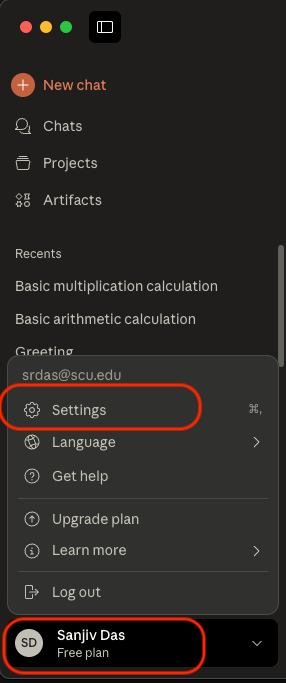

In [ ]:
Image('NLP_images/claude_chat.png', height=600)

Then choose `Developer` to see the running MCP servers.

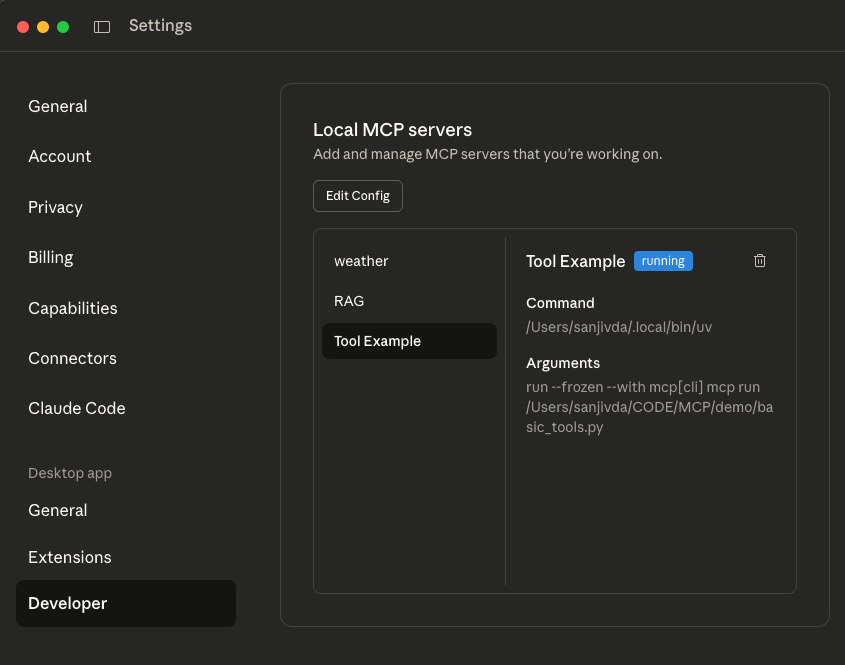

In [ ]:
Image('NLP_images/claude_dev_settings.png', width=600)

Then open `New Chat` to get the following:

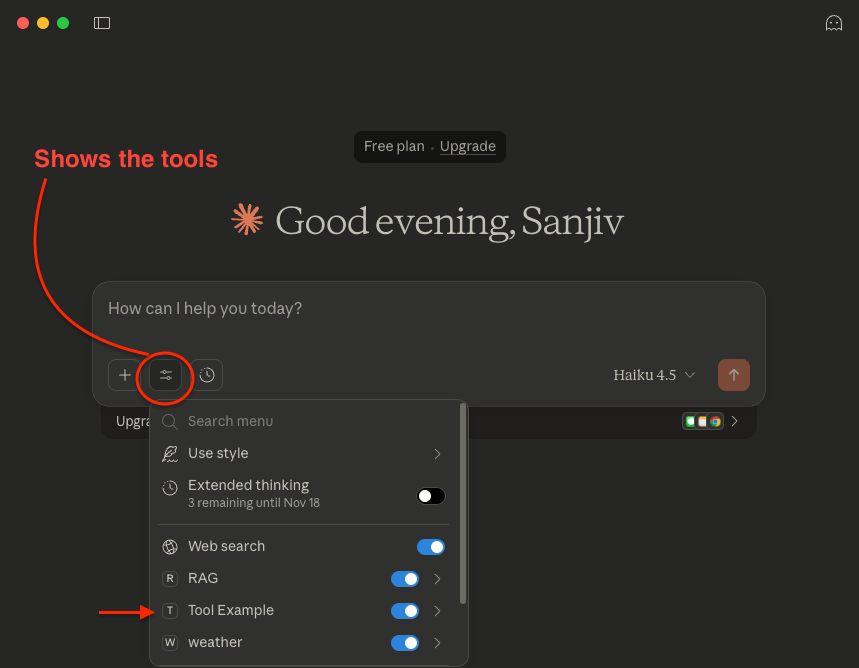

In [ ]:
Image('NLP_images/claude_chat_interface.png', width=800)

See that the tool `T` is used when apt:

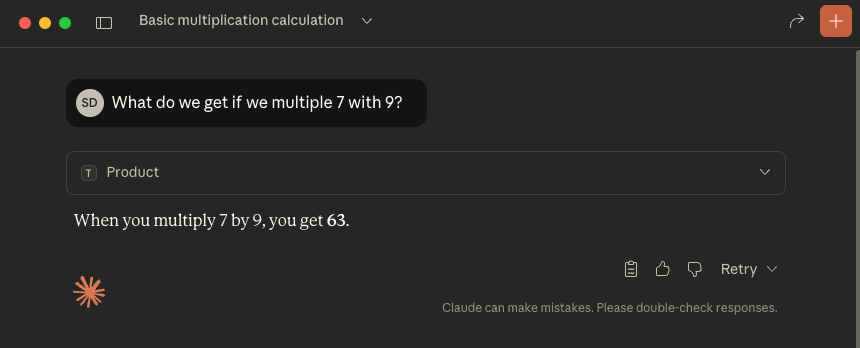

In [ ]:
Image('NLP_images/claude_tool_use.png', width=1000)

Take a look at the other servers that may show you other usage patterns: https://github.com/modelcontextprotocol/python-sdk/tree/main/examples/snippets/servers

## Installing the MCP Server for using the File System

The approach to doing this is to use the `filesystem` MCP server from here: https://github.com/modelcontextprotocol/servers/tree/main/src/filesystem

Copy the NPX config into the  `claude_desktop_config.json` file. This file (on a Mac) is in this folder: `/Users/sanjivda/Library/Application Support/Claude`

```json
{
  "mcpServers": {
    "filesystem": {
      "command": "npx",
      "args": [
        "-y",
        "@modelcontextprotocol/server-filesystem",
        "/Users/username/Desktop",
        "/path/to/other/allowed/dir"
      ]
    }
  }
}
```

Update the paths to the folder above to the actual local folders you want to give access to.

Then restart Claude Desktop and you can issue commands to add files, delete files, etc.

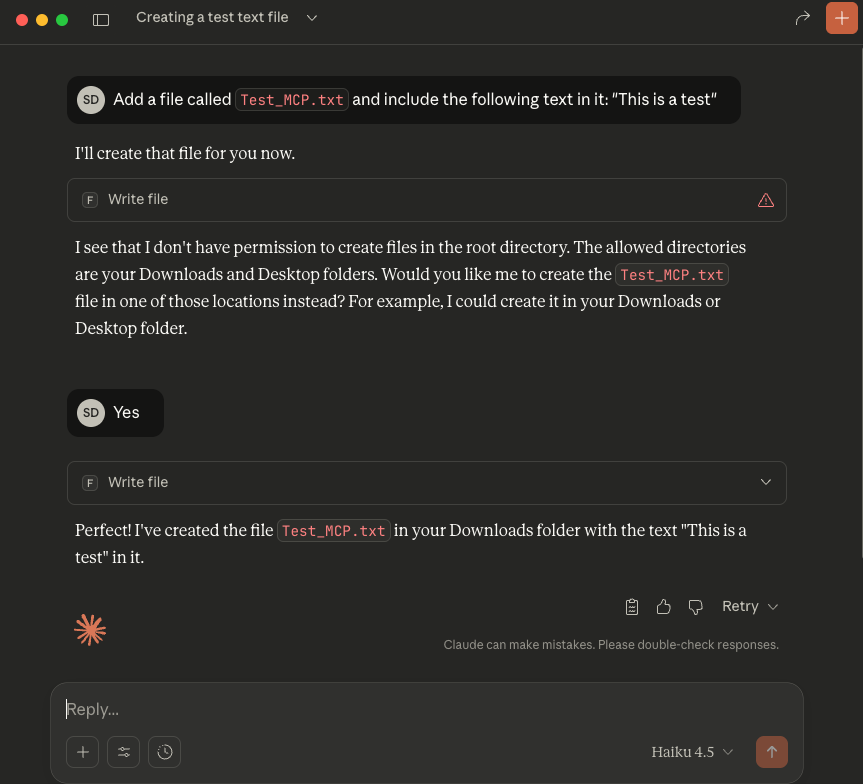

In [ ]:
Image('NLP_images/claude_fileserver.png', width=700)

## Using MCP Servers without Claude Desktop

Here we will create a MCP client so that we can call the MCP server from the command line instead of using Claude Desktop.

First, set up the folder and environment:

```
uv init Client
cd Client
uv venv
source .venv/bin/activate

uv add mcp anthropic python-dotenv

# Remove boilerplate files
rm main.py

# Create client file
touch client.py
```

This creates a client file in the `demo` folder. Grab the base code from [client.py](https://github.com/modelcontextprotocol/quickstart-resources/blob/main/mcp-client-python/client.py)

The client code is explained in detail here: https://modelcontextprotocol.io/docs/develop/build-client

Copy this code into `client.py`:

```python
import asyncio
from typing import Optional
from contextlib import AsyncExitStack

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

from anthropic import Anthropic
from dotenv import load_dotenv

load_dotenv()  # load environment variables from .env

# Claude model constant
ANTHROPIC_MODEL = "claude-sonnet-4-5"

class MCPClient:
    def __init__(self):
        # Initialize session and client objects
        self.session: Optional[ClientSession] = None
        self.exit_stack = AsyncExitStack()
        self.anthropic = Anthropic()

    async def connect_to_server(self, server_script_path: str):
        """Connect to an MCP server
        
        Args:
            server_script_path: Path to the server script (.py or .js)
        """
        is_python = server_script_path.endswith('.py')
        is_js = server_script_path.endswith('.js')
        if not (is_python or is_js):
            raise ValueError("Server script must be a .py or .js file")
            
        command = "python" if is_python else "node"
        server_params = StdioServerParameters(
            command=command,
            args=[server_script_path],
            env=None
        )
        
        stdio_transport = await self.exit_stack.enter_async_context(stdio_client(server_params))
        self.stdio, self.write = stdio_transport
        self.session = await self.exit_stack.enter_async_context(ClientSession(self.stdio, self.write))
        
        await self.session.initialize()
        
        # List available tools
        response = await self.session.list_tools()
        tools = response.tools
        print("\nConnected to server with tools:", [tool.name for tool in tools])

    async def process_query(self, query: str) -> str:
        """Process a query using Claude and available tools"""
        messages = [
            {
                "role": "user",
                "content": query
            }
        ]

        response = await self.session.list_tools()
        available_tools = [{
            "name": tool.name,
            "description": tool.description,
            "input_schema": tool.inputSchema
        } for tool in response.tools]

        # Initial Claude API call
        response = self.anthropic.messages.create(
            model=ANTHROPIC_MODEL,
            max_tokens=1000,
            messages=messages,
            tools=available_tools
        )

        # Process response and handle tool calls
        final_text = []

        for content in response.content:
            if content.type == 'text':
                final_text.append(content.text)
            elif content.type == 'tool_use':
                tool_name = content.name
                tool_args = content.input
                
                # Execute tool call
                result = await self.session.call_tool(tool_name, tool_args)
                final_text.append(f"[Calling tool {tool_name} with args {tool_args}]")

                # Continue conversation with tool results
                if hasattr(content, 'text') and content.text:
                    messages.append({
                      "role": "assistant",
                      "content": content.text
                    })
                messages.append({
                    "role": "user",
                    "content": result.content
                })

                # Get next response from Claude
                response = self.anthropic.messages.create(
                    model=ANTHROPIC_MODEL,
                    max_tokens=1000,
                    messages=messages,
                )

                final_text.append(response.content[0].text)

        return "\n".join(final_text)

    async def chat_loop(self):
        """Run an interactive chat loop"""
        print("\nMCP Client Started!")
        print("Type your queries or 'quit' to exit.")
        
        while True:
            try:
                query = input("\nQuery: ").strip()
                
                if query.lower() == 'quit':
                    break
                    
                response = await self.process_query(query)
                print("\n" + response)
                    
            except Exception as e:
                print(f"\nError: {str(e)}")
    
    async def cleanup(self):
        """Clean up resources"""
        await self.exit_stack.aclose()

async def main():
    if len(sys.argv) < 2:
        print("Usage: python client.py <path_to_server_script>")
        sys.exit(1)
        
    client = MCPClient()
    try:
        await client.connect_to_server(sys.argv[1])
        await client.chat_loop()
    finally:
        await client.cleanup()

if __name__ == "__main__":
    import sys
    asyncio.run(main())
```


Since this code uses Anthropic models, you need to have an API key from Anthropic.

Use the API key as follows:

```
echo "ANTHROPIC_API_KEY=your-api-key" > .env
```

Then use the client to call the server:

```
uv run client.py path/to/basic_tools.py
```

You will then get a prompt to query the server.

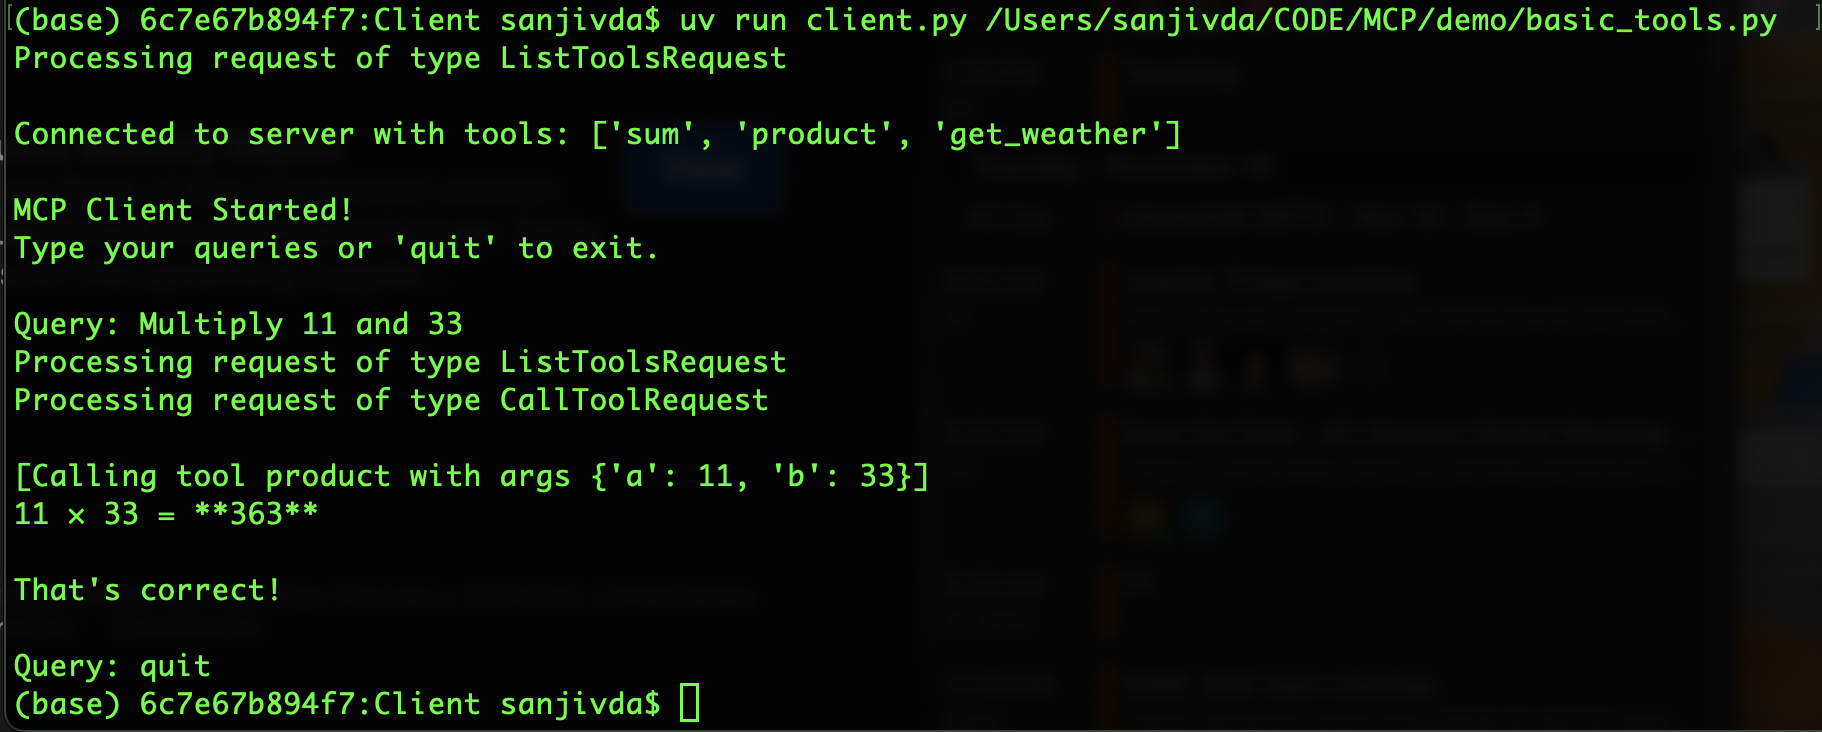

In [ ]:
Image("NLP_images/mcp_client_cli.png", width=1000)

## Using LangChain with MCP

Ref: We use the [langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters) repository for this.

Install required packages:

```
!pip install langchain_mcp_adapters --quiet
!pip install langgraph --quiet
!pip install langchain_openai --quiet
!pip install langchain_ollama --quiet
```

Then create the `math_server.py` file:

```python
# math_server.py
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Math")

@mcp.tool()
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@mcp.tool()
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

if __name__ == "__main__":
    mcp.run(transport="stdio")
```

Note the use of the `FastMCP` server: https://gofastmcp.com/getting-started/welcome

It's much easier to use than Flask.

Next we set up the client code to use Ollama, and here is where `langchain_mcp_adapters` come into play.

```python
# client_ollama.py
# Create server parameters for stdio connection
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain.agents import create_agent
import asyncio

# Set up the driving LLM
from langchain_ollama import ChatOllama
model = ChatOllama(model="gpt-oss")

# from langchain_openai import ChatOpenAI
# model = ChatOpenAI(model="gpt-4o")

server_params = StdioServerParameters(
    command="python",
    # Make sure to update to the full absolute path to your math_server.py file
    args=["math_server.py"],
)

async def run_agent():
    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            # Initialize the connection
            await session.initialize()

            # Get tools
            tools = await load_mcp_tools(session)

            # Create and run the agent
            agent = create_agent(model, tools)
            # agent_response = await agent.ainvoke({"messages": "what's (3 + 5) x 12?"})
            agent_response = await agent.ainvoke({"messages": "What is the product of (2+3) and 5"})
            return agent_response['messages']
        
if __name__ == "__main__":
    result = asyncio.run(run_agent())
    # for j in range(len(result)):
    #     print(j.content, "\n\n", result[j])
    print(result)
```

To run this client, open a terminal and simply use

```
python client_ollama.py
```

You should see the output in the terminal:

```
(mcp) 6c7e67b894f7:Client sanjivda$ python client_ollama.py
[11/28/25 12:09:47] INFO     Processing request of type ListToolsRequest                 server.py:674
[11/28/25 12:09:59] INFO     Processing request of type CallToolRequest                  server.py:674
[HumanMessage(content='What is the product of (2+3) and 5', additional_kwargs={}, response_metadata={}, id='9fae462c-b970-42f1-b164-6858da383c1c'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2025-11-28T20:09:59.455181Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11969445208, 'load_duration': 7387505708, 'prompt_eval_count': 188, 'prompt_eval_duration': 2317610417, 'eval_count': 84, 'eval_duration': 2200469250, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--fe008c7c-0ddb-40a0-a986-5e596f0f1643-0', tool_calls=[{'name': 'product', 'args': {'a': 5, 'b': 5}, 'id': 'ffbe6a10-c162-407e-bdcc-f7fe906e4142', 'type': 'tool_call'}], usage_metadata={'input_tokens': 188, 'output_tokens': 84, 'total_tokens': 272}), ToolMessage(content='25', name='product', id='e8fc78d9-fdfc-450b-847b-a6d9e8769c75', tool_call_id='ffbe6a10-c162-407e-bdcc-f7fe906e4142'), AIMessage(content='The product of \\((2+3)\\) and \\(5\\) is \\(\\boxed{25}\\).', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2025-11-28T20:10:02.355179Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2866222625, 'load_duration': 138992417, 'prompt_eval_count': 220, 'prompt_eval_duration': 260793166, 'eval_count': 92, 'eval_duration': 2403934547, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--e09eaeb8-a324-40a1-89e1-cb627f8630d1-0', usage_metadata={'input_tokens': 220, 'output_tokens': 92, 'total_tokens': 312})]
```

## Multiple MCP Servers with LangChain

Let's add an additional server, called `weather_server.py` with code as follows:

```python
# weather_server.py
from typing import List
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Weather")

@mcp.tool()
async def get_weather(location: str) -> str:
    """Get weather for location."""
    return "It's always sunny in New York"

if __name__ == "__main__":
    mcp.run(transport="stdio")
```


Modifying the code examples from `langchain-mcp-adapters` we create `client.py` and enable it to address multiple MCP servers (the math and weather servers):

```python
# Create server parameters for stdio connection
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents import create_agent
import asyncio

# Set up the driving LLM
from langchain_ollama import ChatOllama
model = ChatOllama(model="gpt-oss")
# from langchain_openai import ChatOpenAI
# model = ChatOpenAI(model="gpt-4.1")

client = MultiServerMCPClient(
    {
        "math": {
            "command": "python",
            # Make sure to update to the full absolute path to your math_server.py file
            "args": ["/Users/sanjivda/CODE/MCP/Client/math_server.py"],
            "transport": "stdio",
        },
        "weather": {
            "command": "python",
            "args": ["/Users/sanjivda/CODE/MCP/Client/weather_server.py"],
            "transport": "stdio",
        }
    }
)

async def run_agent():
    # Get tools
    tools = await client.get_tools()

    # Create and run the agent
    agent = create_agent(model, tools)
    # agent_response = await agent.ainvoke({"messages": "what's (3 + 5) x 12?"})
    agent_response = await agent.ainvoke({"messages": "What is the weather in New York?"})
    return agent_response['messages']
        
if __name__ == "__main__":
    result = asyncio.run(run_agent())
    print(result)

```

This code is seemingly simpler!

Then run the code with

```
python client.py
```

You should see the output as follows:

```
(mcp) 6c7e67b894f7:Client sanjivda$ python client.py
[11/28/25 12:12:23] INFO     Processing request of type ListToolsRequest                 server.py:674
[11/28/25 12:12:23] INFO     Processing request of type ListToolsRequest                 server.py:674
[11/28/25 12:12:29] INFO     Processing request of type CallToolRequest                  server.py:674
                    INFO     Processing request of type ListToolsRequest                 server.py:674
[HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='302c45c3-54af-4e1e-99a9-19dafce8674c'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2025-11-28T20:12:28.747869Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5592563291, 'load_duration': 148727291, 'prompt_eval_count': 175, 'prompt_eval_duration': 4582759916, 'eval_count': 33, 'eval_duration': 845089084, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--3d83e40a-f98e-466c-a2bc-91c8ceda3be4-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'New York'}, 'id': '5fbd8787-2740-4644-a274-8ef7fa1e6600', 'type': 'tool_call'}], usage_metadata={'input_tokens': 175, 'output_tokens': 33, 'total_tokens': 208}), ToolMessage(content="It's always sunny in New York", name='get_weather', id='348cf9a0-33c7-4391-b8f8-58eff7e06b62', tool_call_id='5fbd8787-2740-4644-a274-8ef7fa1e6600'), AIMessage(content='It’s always sunny in New\xa0York! ☀️  \nIf you’re looking for current temperatures, humidity, or wind speeds, let me know and I can fetch the latest data.', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2025-11-28T20:12:32.068035Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2841815333, 'load_duration': 161325833, 'prompt_eval_count': 210, 'prompt_eval_duration': 214878042, 'eval_count': 92, 'eval_duration': 2430542664, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--3821204f-6bd8-4013-a625-16506a9d1fc1-0', usage_metadata={'input_tokens': 210, 'output_tokens': 92, 'total_tokens': 302})]
```

## Extended Reading

- Claude Skills Cookbook: https://github.com/anthropics/claude-cookbooks/tree/main/skills

- Claude Tool Search: https://www.anthropic.com/engineering/advanced-tool-use
